In [15]:
import matplotlib.pyplot as plt
from ipywidgets import interact_manual
import math
import numpy
import ipywidgets as widgets

In [18]:
global e, me, c, h
e=1.602*10**-19
h=6.626*10**-34
me=9.109*10**-31
c=299792458
def WavelengthCalc(V):
    return h/math.sqrt(2*me*e*V*(1+(e*V)/(2*me*c**2)))

def xCalc(Voltage,d):
    Radi=[]
    d2=d*10**-9
    for V in Voltage:
        x=[]
        Lamba=WavelengthCalc(V)
        nMax=math.floor(2*d2/Lamba)
        for y in range(1,nMax+1):
            theta=math.asin(min(1.0,(y*Lamba)/(2*d2)))
            val=65*math.sin(2*theta)
            x.append(val)
        Radi.append(x)
    return Radi
        

def Expirment(TestNum):
    global X0123, X0213,Voltage
    Voltage=numpy.linspace(1000,5000,TestNum)
    X0123=xCalc(Voltage,0.123)
    X0213=xCalc(Voltage,0.213)

interact_manual(
    Expirment,
    TestNum=widgets.IntSlider(value=200, min=100,max=4000,step=100,description='Number Of Voltage Calculations')
)

interactive(children=(IntSlider(value=200, description='Number Of Voltage Calculations', max=4000, min=100, st…

<function __main__.Expirment(TestNum)>

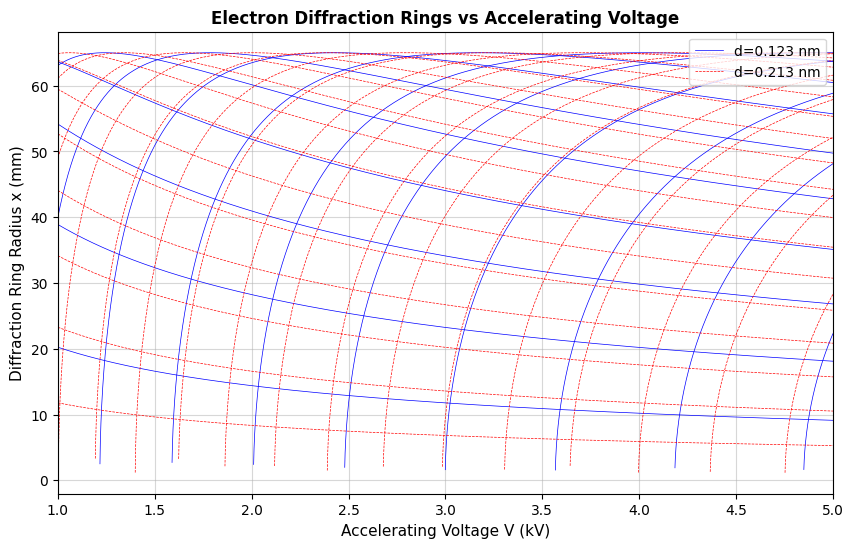

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.grid(True, alpha=0.5)

V_kV = Voltage / 1000.0

max_rings_0123 = max(len(row) for row in X0123)
max_rings_0213 = max(len(row) for row in X0213)

for n_idx in range(max_rings_0123):
    line_v = []
    line_x = []
    for i, row in enumerate(X0123):
        if n_idx < len(row) and row[n_idx] > 0.5: # Cut off truncation artifacts near 0
            line_v.append(V_kV[i])
            line_x.append(row[n_idx])
    if line_x:
        ax.plot(line_v, line_x, color='blue', linewidth=0.5, 
                label='d=0.123 nm' if n_idx == 0 else "")

for n_idx in range(max_rings_0213):
    line_v = []
    line_x = []
    for i, row in enumerate(X0213):
        if n_idx < len(row) and row[n_idx] > 0.5:
            line_v.append(V_kV[i])
            line_x.append(row[n_idx])
    if line_x:
        ax.plot(line_v, line_x, color='red', linestyle='--', linewidth=0.5, 
                label='d=0.213 nm' if n_idx == 0 else "")

ax.set_xlabel("Accelerating Voltage V (kV)", fontsize=11)
ax.set_ylabel("Diffraction Ring Radius x (mm)", fontsize=11)
ax.set_title("Electron Diffraction Rings vs Accelerating Voltage", fontsize=12, fontweight='bold')
ax.set_xlim(1.0, 5.0)

ax.legend(loc='upper right', frameon=True)

plt.show()